In [1]:
import pandas as pd
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import mplcursors
import seaborn as sns
import numpy as np
import ast
from itertools import combinations
from collections import Counter
import re
from IPython.display import Image, display

In [2]:
%matplotlib tk

In [3]:
url = "https://raw.githubusercontent.com/me9hanics/PainterPalette/main/datasets/artists.csv"
artists = pd.read_csv(url)

In [4]:
artists = artists.dropna(subset=['birth_year'])
print(artists.shape)

(9456, 30)


In [5]:
# split the artists into the century block that they belong
artists_14c = artists[(artists['birth_year'] >= 1300) & (artists['birth_year'] < 1400)]
artists_15c = artists[(artists['birth_year'] >= 1400) & (artists['birth_year'] < 1500)]
artists_16c = artists[(artists['birth_year'] >= 1500) & (artists['birth_year'] < 1600)]
artists_17c = artists[(artists['birth_year'] >= 1600) & (artists['birth_year'] < 1700)]
artists_18c = artists[(artists['birth_year'] >= 1700) & (artists['birth_year'] < 1800)]
artists_19c = artists[(artists['birth_year'] >= 1800) & (artists['birth_year'] < 1900)]
artists_20c = artists[(artists['birth_year'] >= 1900) & (artists['birth_year'] < 2100)] # also includes 21st-century artists since they are so sparse

In [6]:
def parse_styles(s):
  return {k: int(v) for k, v in re.findall(r'\{([^:]+):(\d+)\}', s)}

In [38]:
# color edges based on shared style (try later w/ weighting to prioritize which shared style is used for coloring); weight the edges based on # of shared styles
# using styles_extended to count
def style_share(artists):
  G = nx.Graph()
  artists = artists[["artist", "styles_extended"]]
  artists = artists.dropna()

  G.add_nodes_from(artists["artist"])

  artists['styles'] = artists['styles_extended'].apply(parse_styles)

  print(artists.head())

  styles_to_artists = dict()
  for index, row in artists.iterrows():
    for style in row["styles"].keys():
      if style != 'Unknown':
        if style in styles_to_artists:
          styles_to_artists[style][row['artist']] = row['styles'][style]
        else:
          styles_to_artists[style] = {row["artist"]: row['styles'][style]}

  for style in styles_to_artists:
    artists = styles_to_artists[style].keys()
    for artist1 in artists:
      for artist2 in artists:
        style_overlap = min(styles_to_artists[style][artist1], styles_to_artists[style][artist2])
        if artist1 != artist2 and not G.has_edge(artist1, artist2):
          G.add_edge(artist1, artist2, weight=style_overlap, styles={style: style_overlap})
        elif G.has_edge(artist1, artist2): # increment weight and add style to dictionary
          G[artist1][artist2]['weight'] += style_overlap
          G[artist1][artist2]['styles'][style] = style_overlap
  
  style_counts = nx.get_edge_attributes(G, "styles")

  # set dominant style
  for edge in style_counts:
    edge_styles = style_counts[edge]
    largest_style = max(edge_styles, key=edge_styles.get)
    G[edge[0]][edge[1]]['style'] = largest_style

  # Create colormap for styles
  styles = set(nx.get_edge_attributes(G, 'style').values())
  cmap = plt.get_cmap('rainbow')

  # Map each style to a color
  color_map = {style: cmap(i / len(styles)) for i, style in enumerate(styles)}

  # Add color attribute to edges
  for u, v in G.edges():
    G[u][v]['color'] = color_map.get(G[u][v].get('style'), 'gray')

  # drop nodes without any edges
  isolated_nodes = list(nx.isolates(G))
  G.remove_nodes_from(isolated_nodes)

  return G

In [17]:
def visualize_style_sharing(G, tag, labels=False):
  plt.rcParams['toolbar'] = 'toolbar2' # add zoom option
  fig, ax = plt.subplots(figsize=(10, 10)) # Increase figure size for better visibility
  pos = nx.spring_layout(G, k=2.0, iterations=50, seed=42) # Use spring layout with increased 'k' for spacing
  edge_colors = [G[u][v]['color'] for u, v in G.edges()]
  edge_styles = [G[u][v]['style'] for u, v in G.edges()]
  top_10_styles = {style for style, _ in Counter(edge_styles).most_common(10)}
  color_map = {G[u][v]['style']: G[u][v]['color'] for u, v in G.edges()}
  legend_handles = [mpatches.Patch(color=color, label=style) for style, color in color_map.items() if style in top_10_styles]
  nx.draw_networkx(G, pos, edge_color=edge_colors, with_labels=labels, node_size=40, font_size=8)

  # make text more transparent
  for text in ax.texts:
      text.set_alpha(0.6)
  plt.legend(handles=legend_handles)
  plt.title('Shared Styles Network (' + tag + ' Artists)')
  plt.axis('off')

  # save before show
  fig.savefig('visualization.png', dpi=150, bbox_inches='tight')

  # display static version inline
  display(Image('visualization.png'))

  # then open interactive window
  plt.show()

In [11]:
def visualize_greedy_modularity_clusters_style(G, tag, labels=False):
  communities = greedy_modularity_communities(G, weight='weight')

  def dominant_style(G, nodes):
    styles = []
    for u, v in G.subgraph(community).edges():
        styles.append(G[u][v]['style'])
    return Counter(styles).most_common(1)[0][0]
  
  plt.rcParams['toolbar'] = 'toolbar2' # add zoom option
  fig, ax = plt.subplots(figsize=(10, 10))

  # build subgraph for each community
  community_map = {}
  for i, community in enumerate(communities):
      for node in community:
          community_map[node] = i

  C = nx.Graph()
  C.add_nodes_from(range(len(communities)))
  for u, v in G.edges():
      cu, cv = community_map[u], community_map[v]
      if cu != cv:
          if C.has_edge(cu, cv):
              C[cu][cv]['weight'] += 1
          else:
              C.add_edge(cu, cv, weight=1)

  community_pos = nx.spring_layout(C, k=4.0, iterations=100, seed=42)

  # lay out nodes within each community, then offset globally
  pos = {}
  for i, community in enumerate(communities):
      subgraph = G.subgraph(community)
      if len(community) == 1:
          node = list(community)[0]
          pos[node] = community_pos[i]
          continue

      sub_pos = nx.spring_layout(subgraph, k=1.5, iterations=50, seed=42)

      scale = max(0.05, min(1.5, len(community) / len(G.nodes()) * 2))

      # scale down and offset to community center
      for node, (x, y) in sub_pos.items():
          cx, cy = community_pos[i]
          pos[node] = (cx + x * scale, cy + y * scale)

  # pos = nx.spring_layout(G, k=2.0, iterations=50, seed=42)

  edge_colors = [G[u][v]['color'] for u, v in G.edges()]
  top_10_colors = {color for color, _ in Counter(edge_colors).most_common(10)}
  color_map = {G[u][v]['style']: G[u][v]['color'] for u, v in G.edges()}
  legend_handles = [mpatches.Patch(color=color, label=loc) for loc, color in color_map.items() if color in top_10_colors]
  nx.draw_networkx_edges(G, pos, edge_color=edge_colors, alpha=0.4)
  nodes = nx.draw_networkx_nodes(G, pos, node_size=20)
  cursor = mplcursors.cursor(nodes, hover=True)

  @cursor.connect("add") # adding label on hover
  def on_add(sel):
    node = list(G.nodes())[sel.index]
    sel.annotation.set_text(node)

  if labels: # only label most connected nodes
    node_labels = {}
    for i, community in enumerate(communities):
        top_nodes = sorted(community, key=lambda n: G.degree(n), reverse=True)[:3]
        for node in top_nodes:
            node_labels[node] = node
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8)

  # make text more transparent
  for text in ax.texts:
      text.set_alpha(0.6)

  # Draw a circle around each community
  for i, community in enumerate(communities):
    if len(community) < 2:
       continue
    
    style = dominant_style(G, community)
    color = color_map[style]
    
    community_pos = [pos[n] for n in community]
    x = [p[0] for p in community_pos]
    y = [p[1] for p in community_pos]
    cx, cy = sum(x) / len(x), sum(y) / len(y)
    radius = max(((px - cx)**2 + (py - cy)**2)**0.5 for px, py in community_pos) + 0.1
    circle = mpatches.Circle((cx, cy), radius, fill=False, linewidth=2, edgecolor=color)
    ax.add_patch(circle)

    ax.text(cx, cy + radius + 0.02, style,
        ha='center', va='bottom',
        fontsize=9, color=color,
        fontweight='bold')
  
  ax.autoscale()
  
  plt.legend(handles=legend_handles)
  plt.title('Style Sharing Network (' + tag + ' Artists)')
  plt.axis('off')

  # save before show
  fig.savefig('visualization.png', dpi=150, bbox_inches='tight')

  # display static version inline
  display(Image('visualization.png'))

  # then open interactive window
  plt.show()

                    artist                      styles_extended  \
68      Giovanni da Milano               {Proto Renaissance:86}   
114          Luca di Tommé               {Proto Renaissance:41}   
1342             Donatello   {Early Renaissance:12},{Unknown:4}   
1344  Filippo Brunelleschi               {Early Renaissance:13}   
1346          Fra Angelico  {Early Renaissance:160},{Unknown:8}   

                                        styles  
68                   {'Proto Renaissance': 86}  
114                  {'Proto Renaissance': 41}  
1342   {'Early Renaissance': 12, 'Unknown': 4}  
1344                 {'Early Renaissance': 13}  
1346  {'Early Renaissance': 160, 'Unknown': 8}  


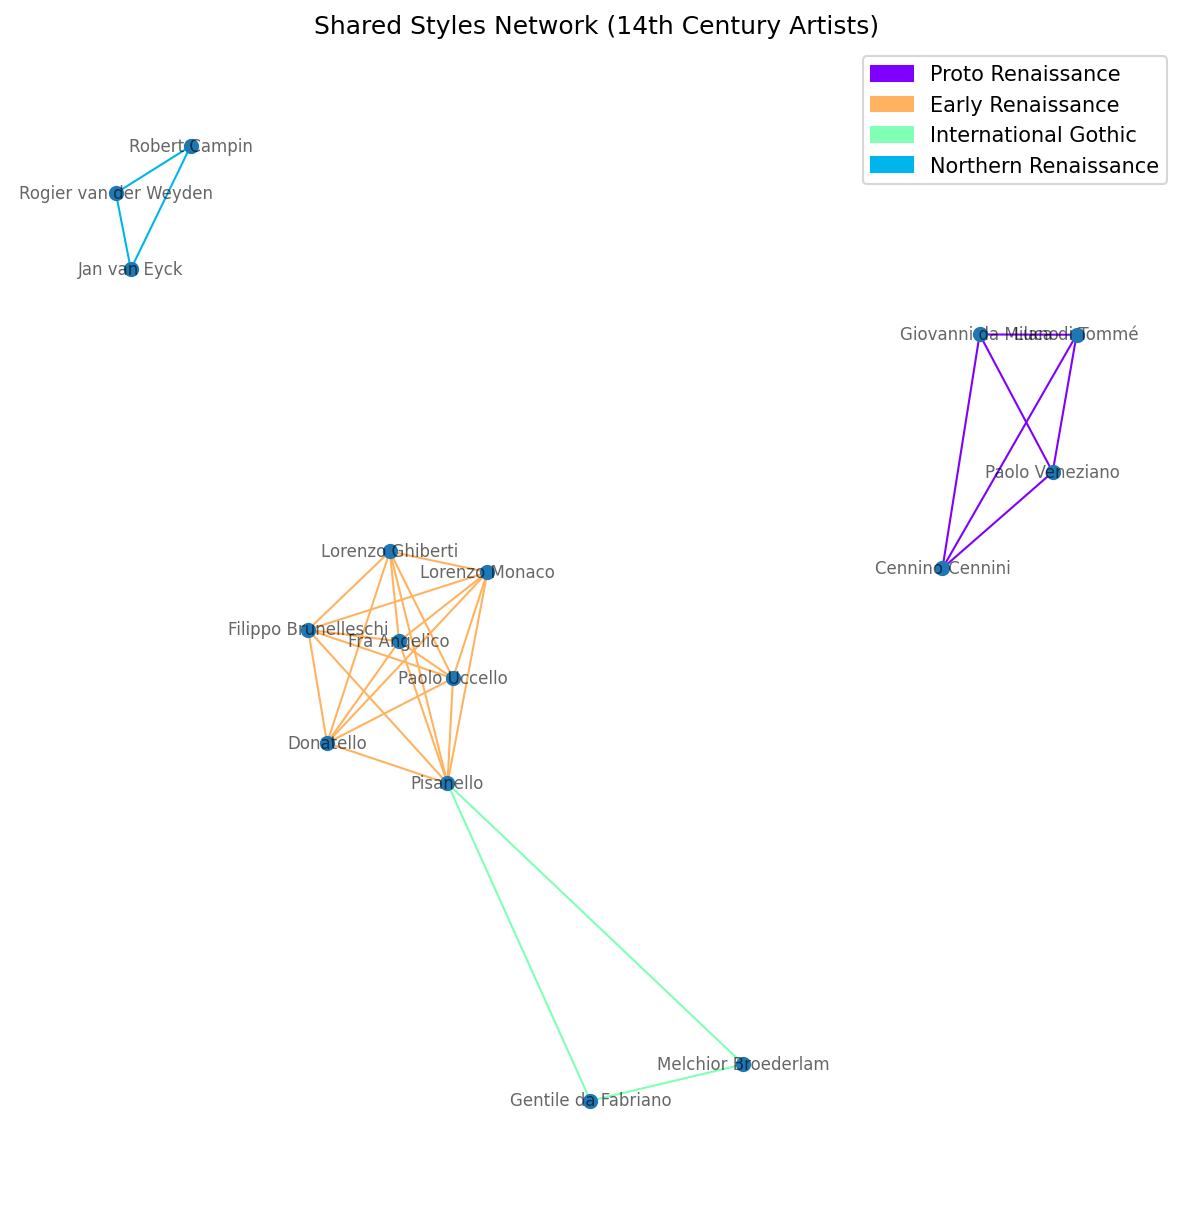

In [39]:
style_share_14c = style_share(artists_14c)
visualize_style_sharing(style_share_14c, "14th Century", True)

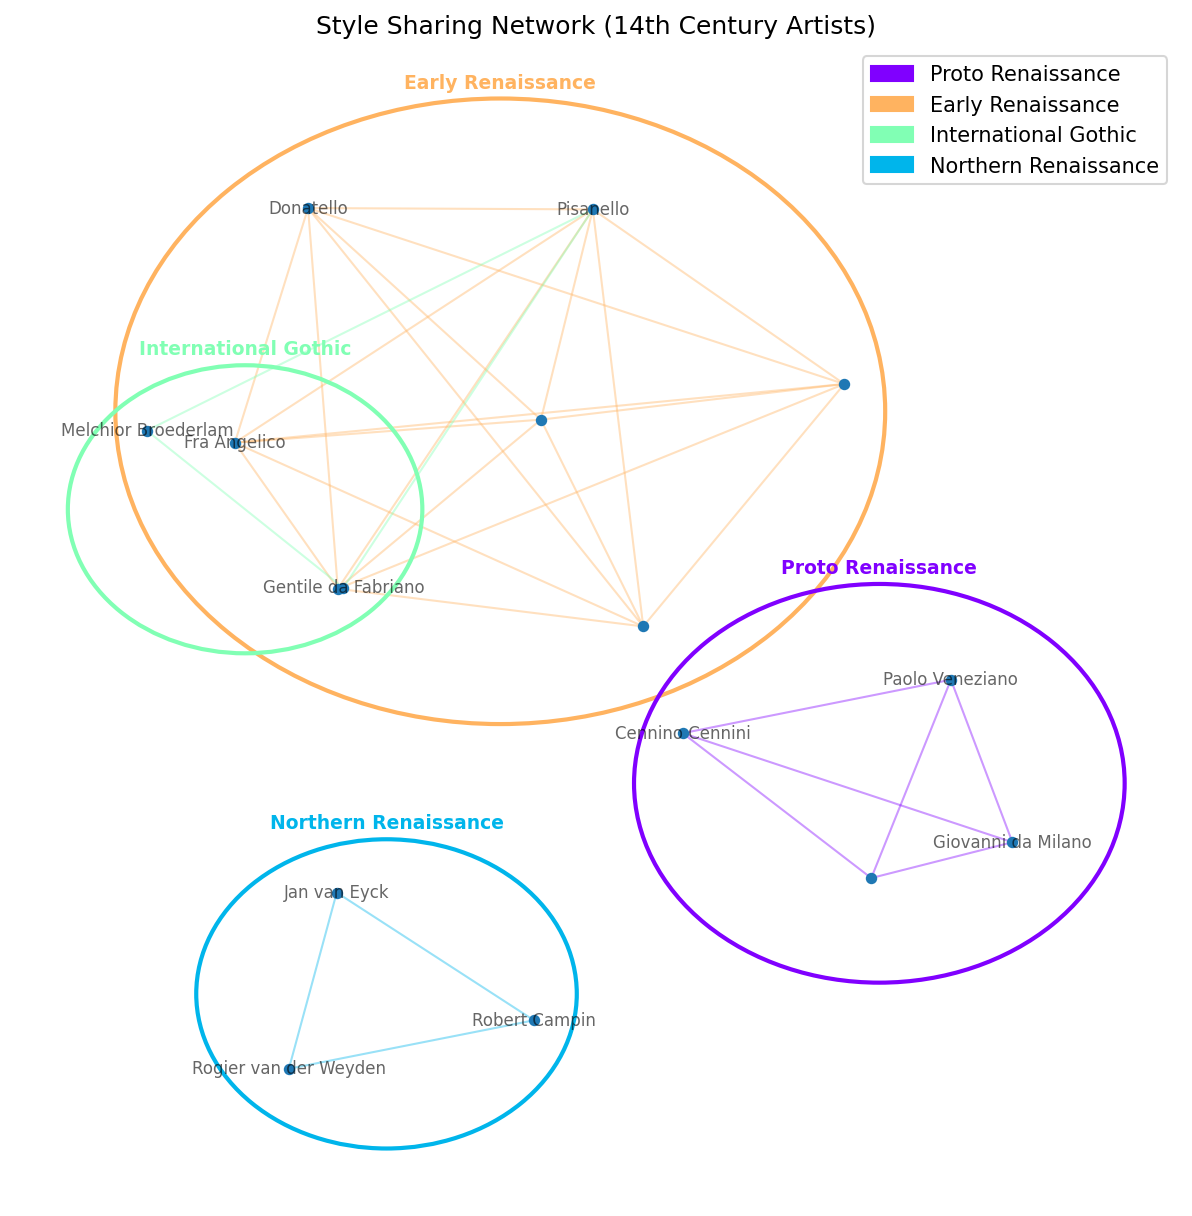

In [19]:
visualize_greedy_modularity_clusters_style(style_share_14c, "14th Century", True)

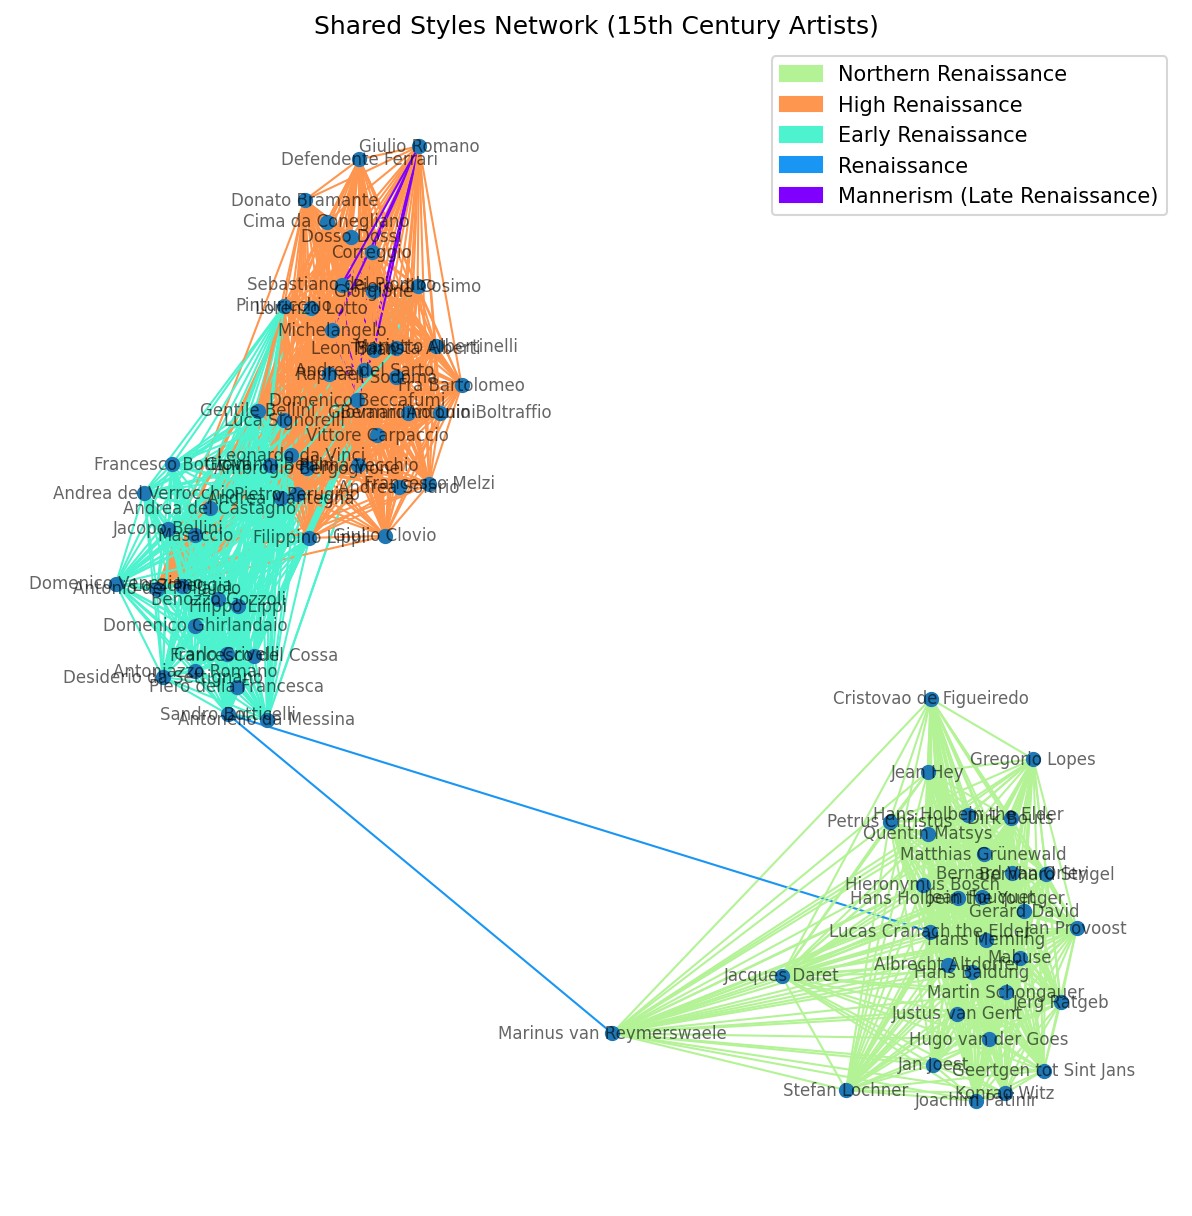

In [22]:
style_share_15c = style_share(artists_15c)
visualize_style_sharing(style_share_15c, "15th Century", True)

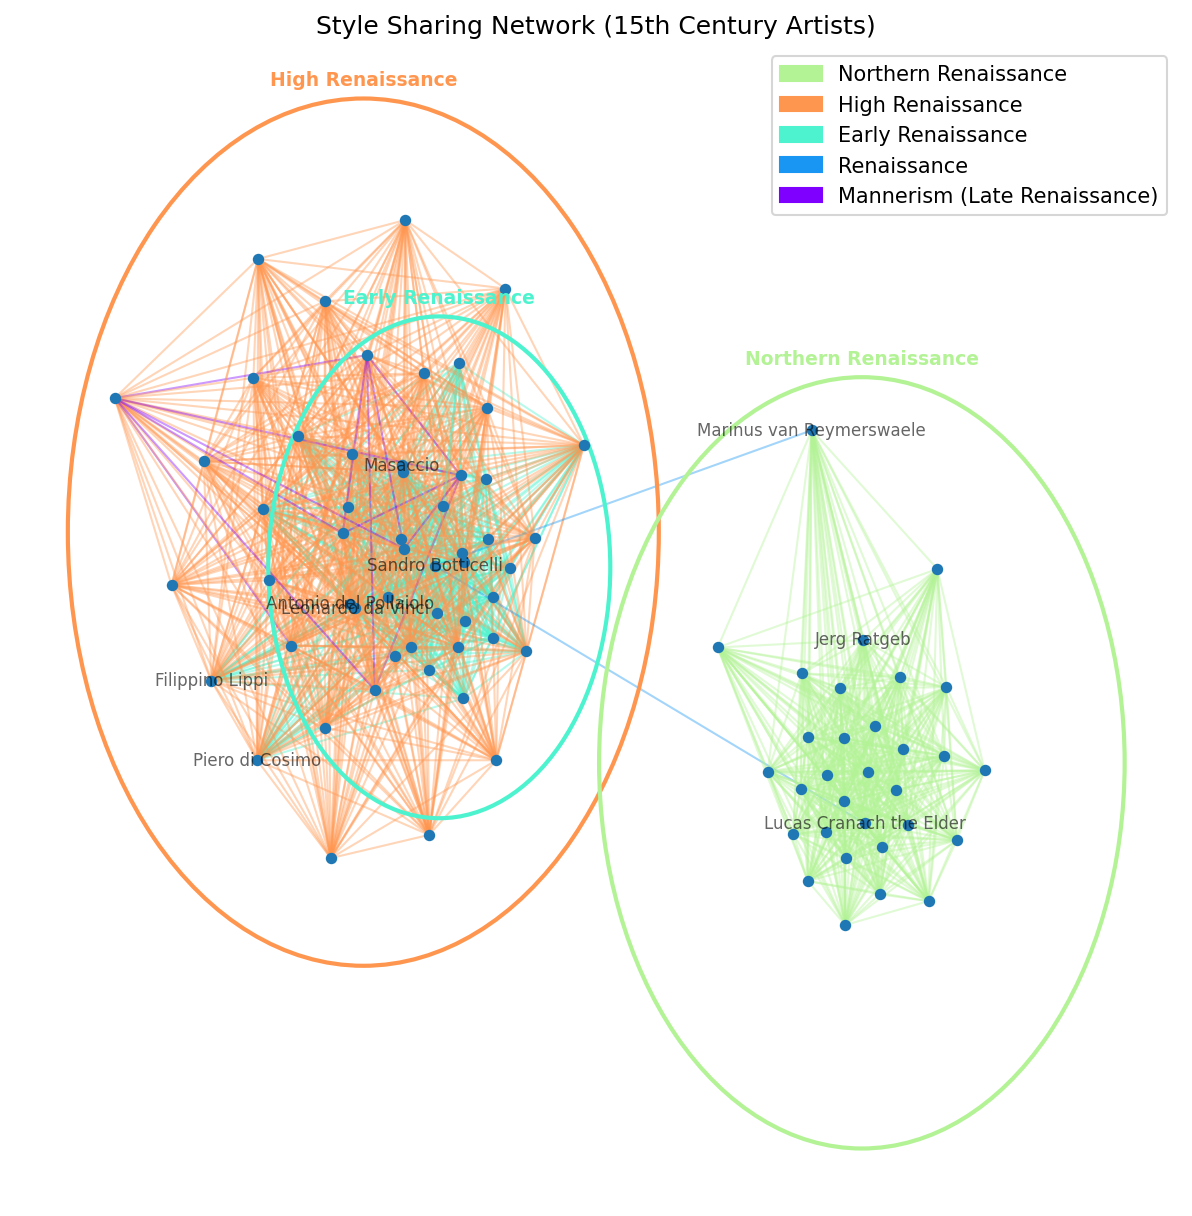

In [23]:
visualize_greedy_modularity_clusters_style(style_share_15c, "15th Century", True)

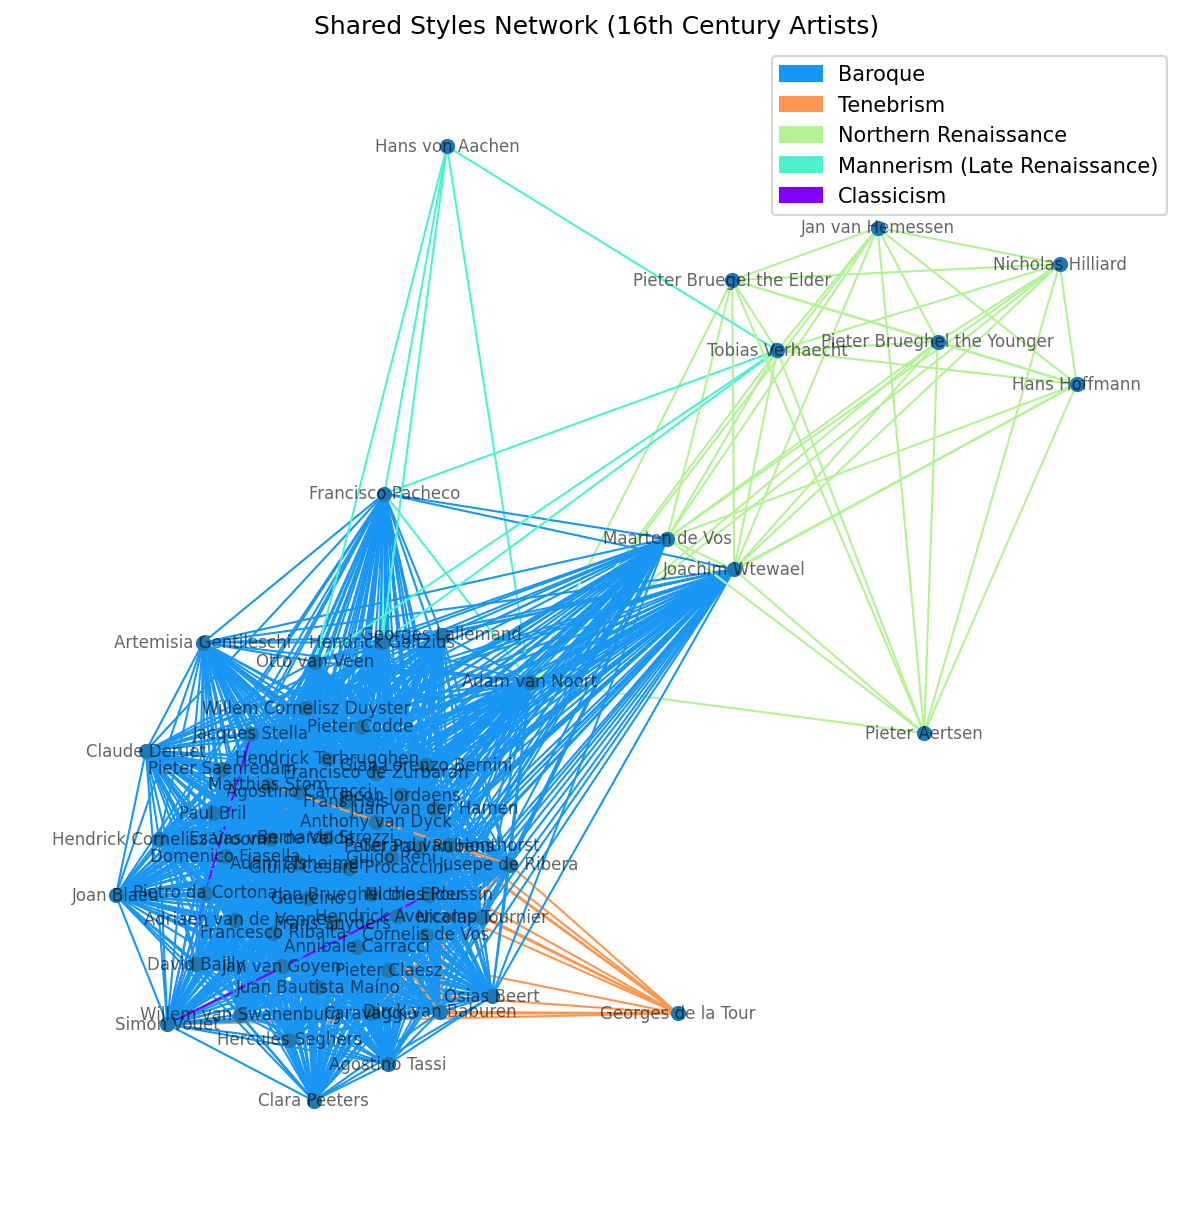

In [24]:
style_share_16c = style_share(artists_16c)
visualize_style_sharing(style_share_16c, "16th Century", True)

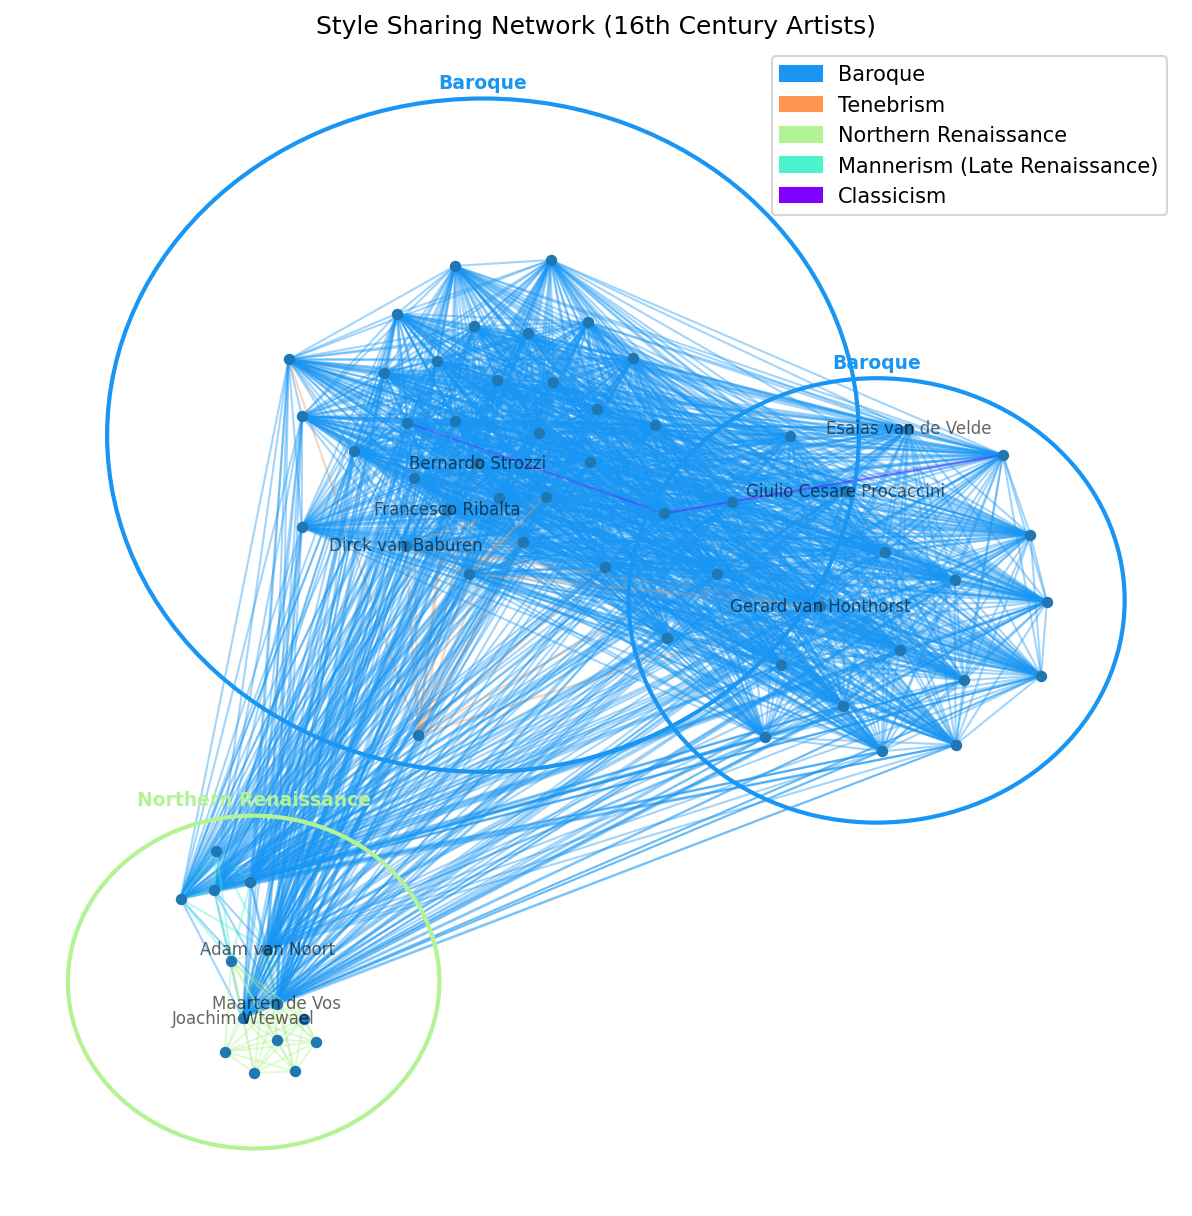

In [25]:
visualize_greedy_modularity_clusters_style(style_share_16c, "16th Century", True)

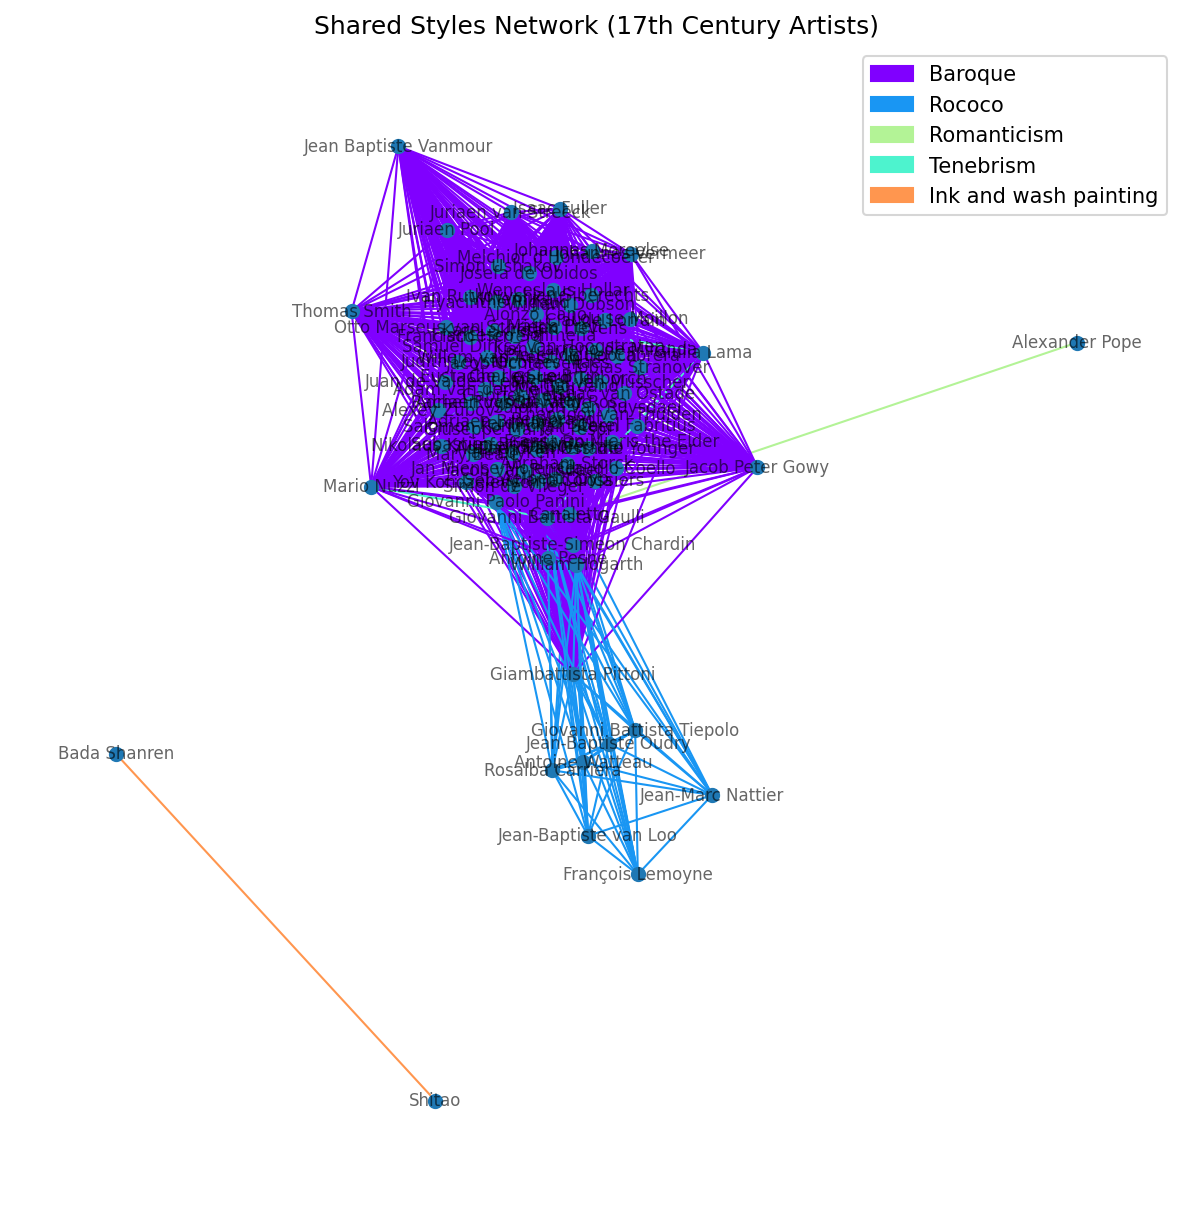

In [26]:
style_share_17c = style_share(artists_17c)
visualize_style_sharing(style_share_17c, "17th Century", True)

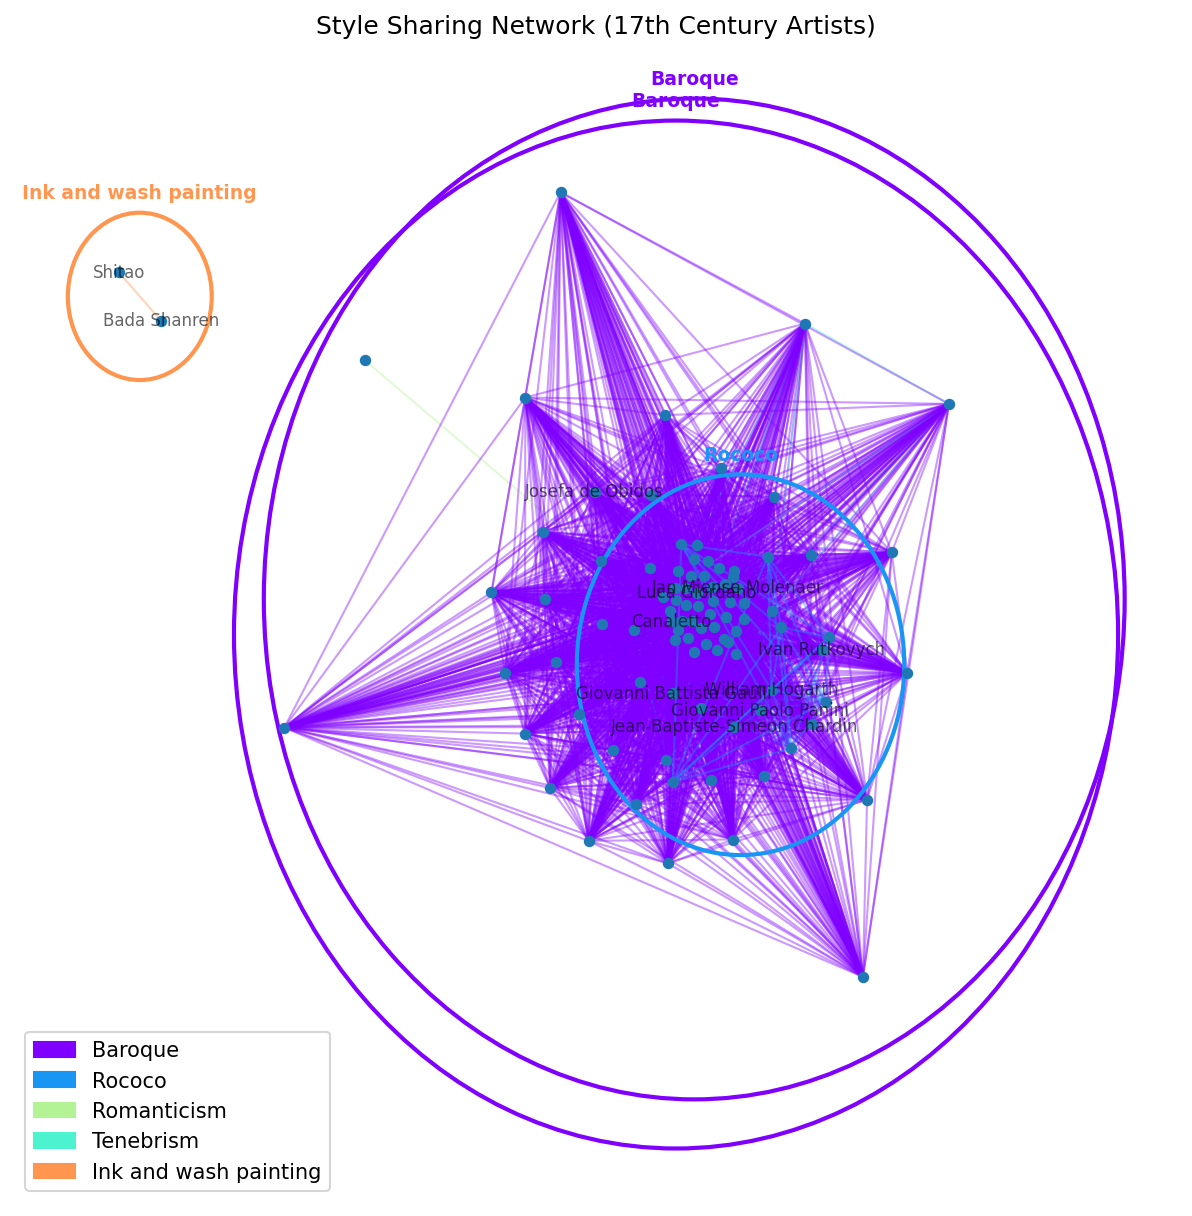

In [27]:
visualize_greedy_modularity_clusters_style(style_share_17c, "17th Century", True)

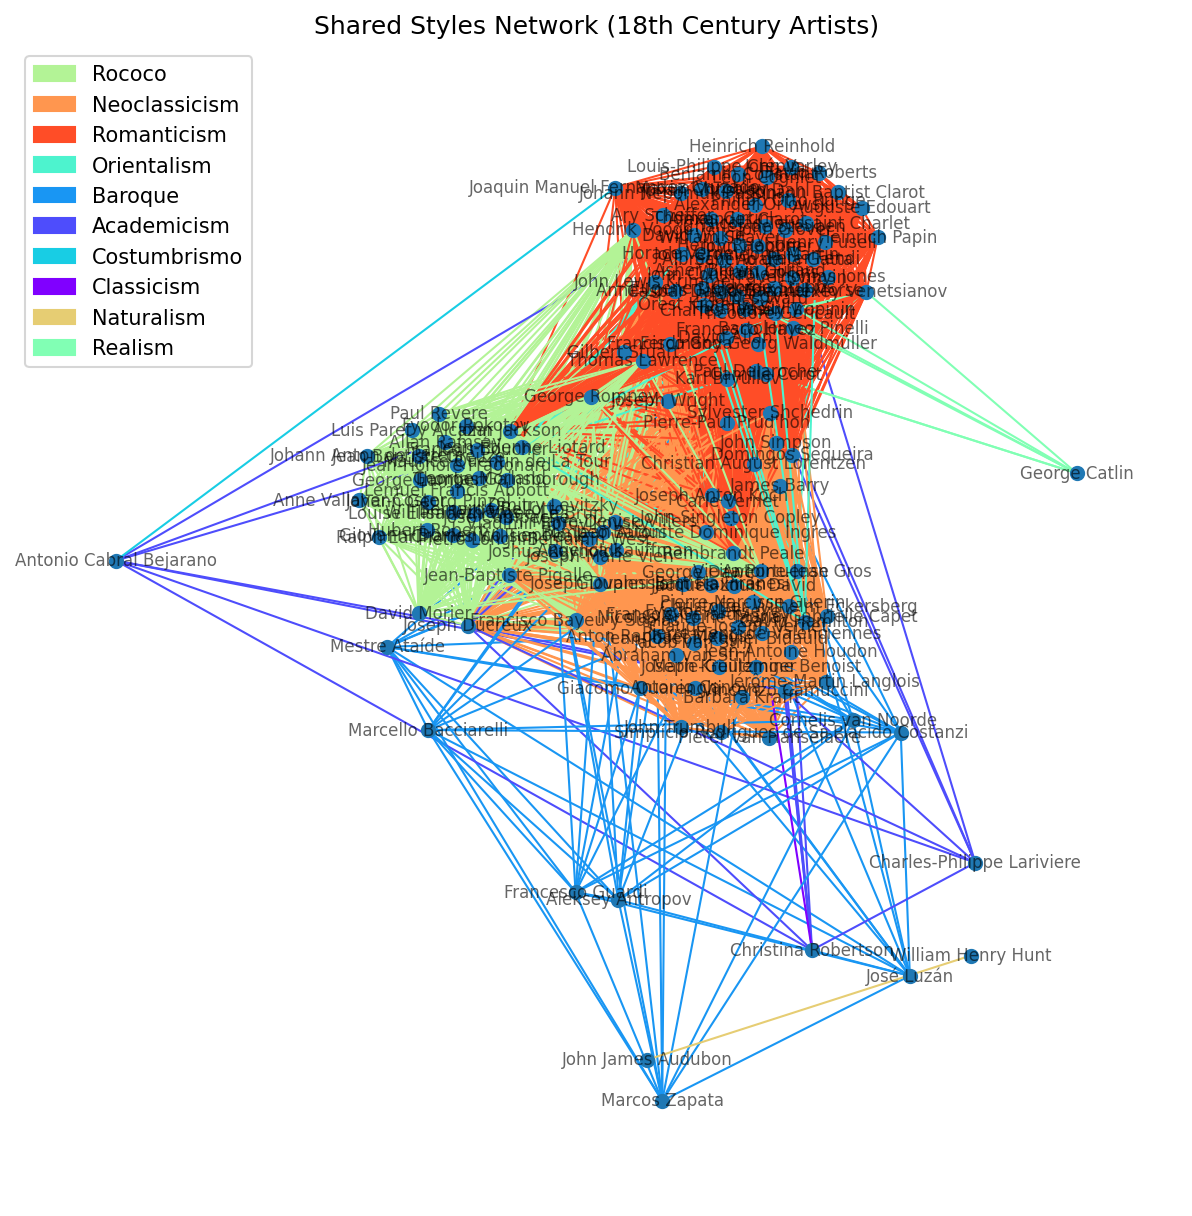

In [28]:
style_share_18c = style_share(artists_18c)
visualize_style_sharing(style_share_18c, "18th Century", True)

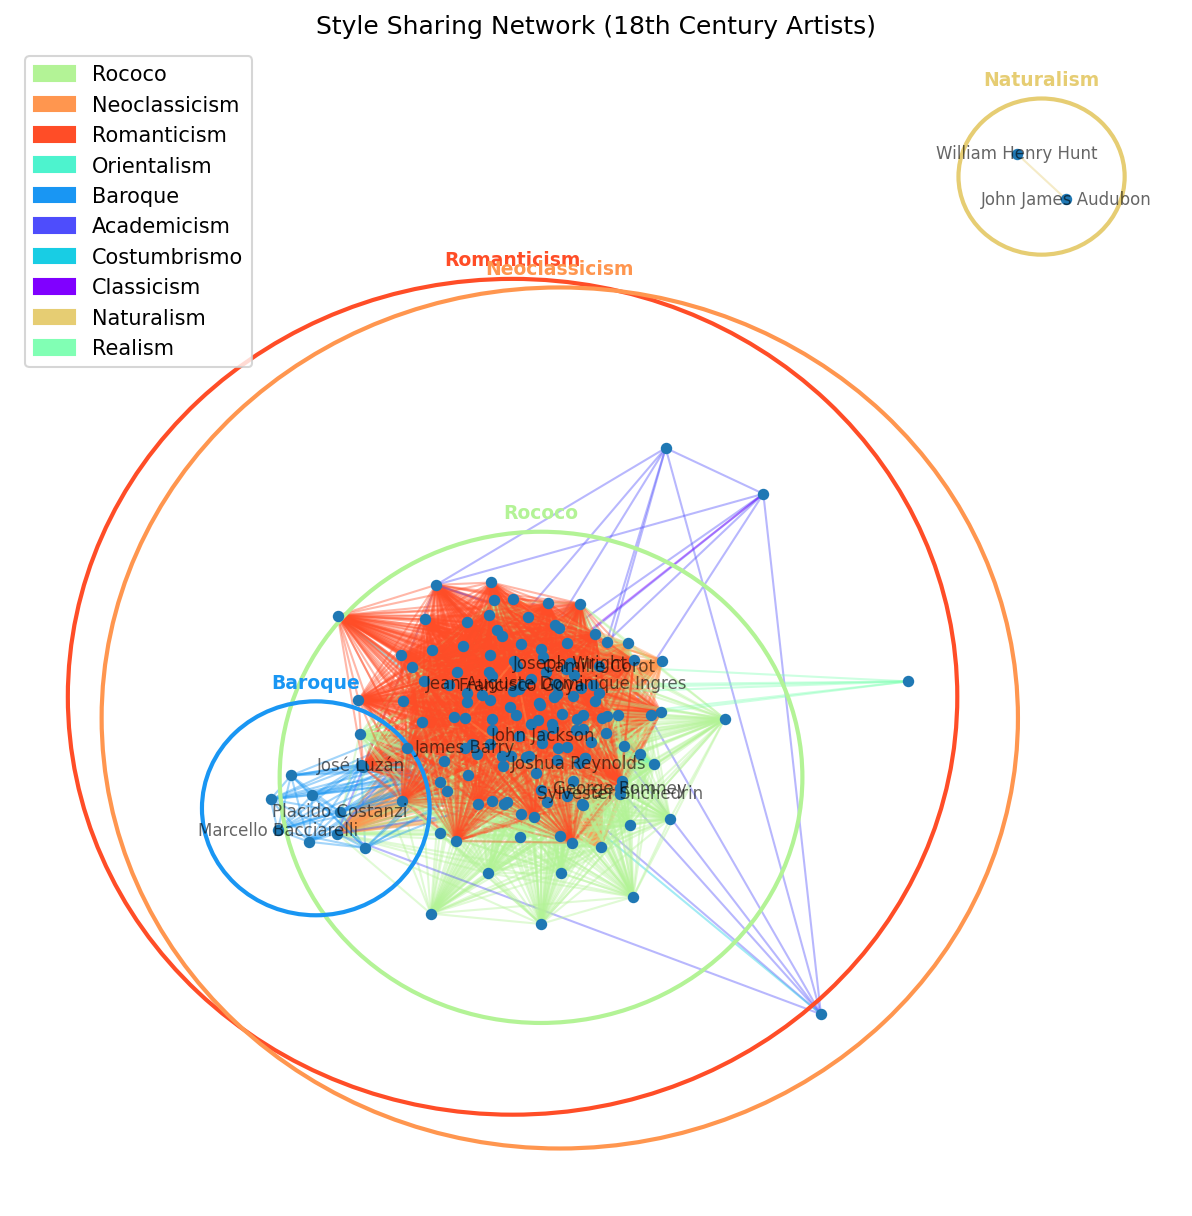

In [29]:
visualize_greedy_modularity_clusters_style(style_share_18c, "18th Century", True)

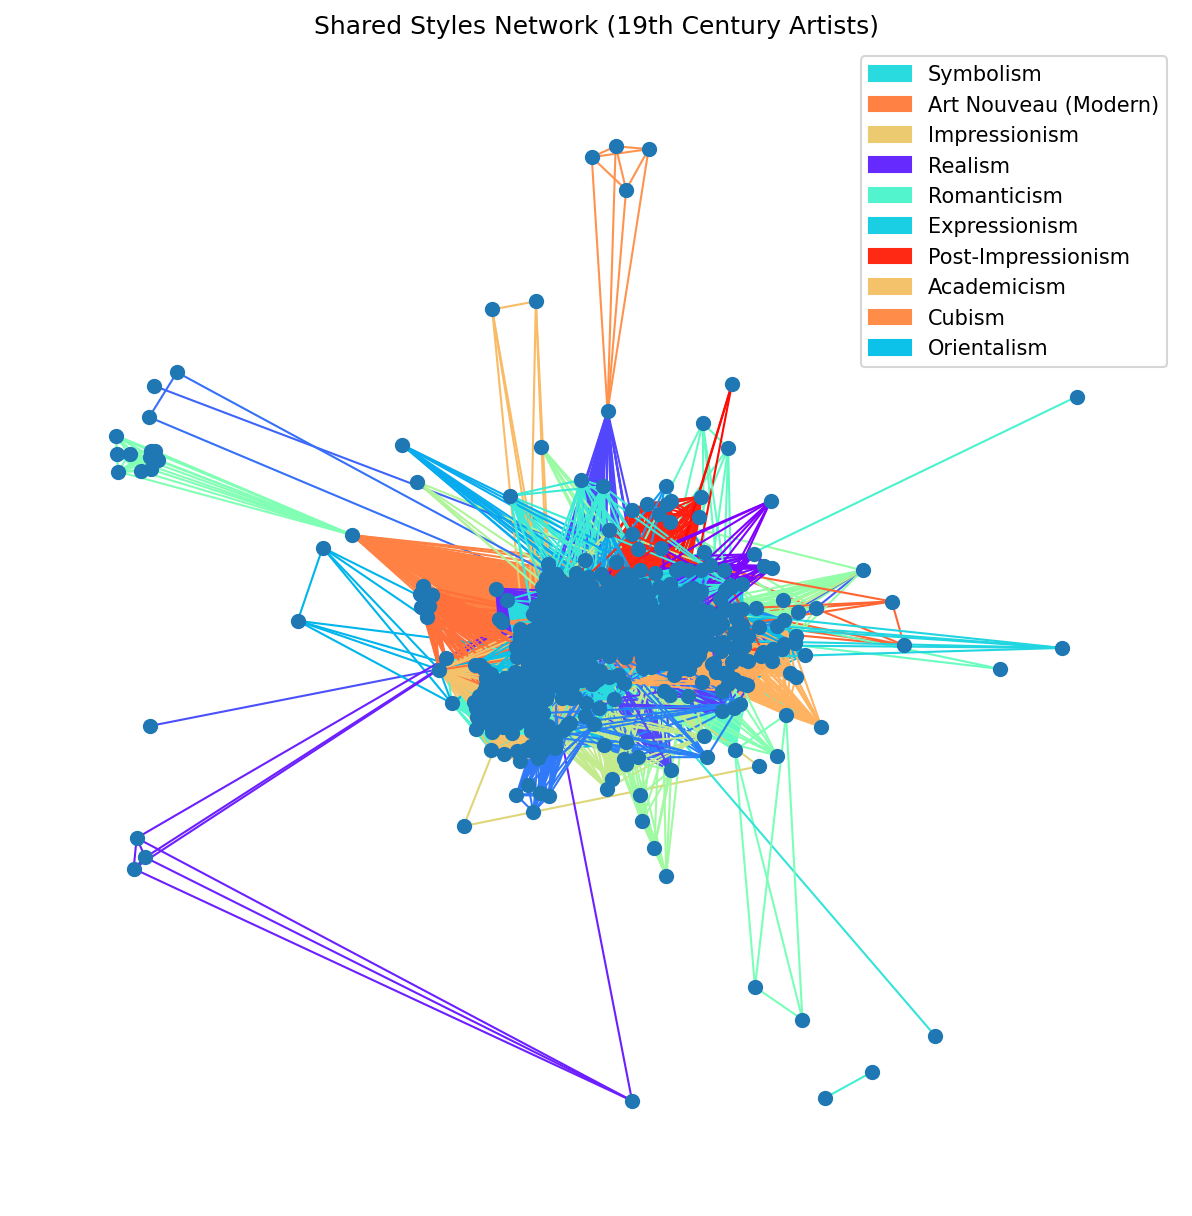

In [31]:
style_share_19c = style_share(artists_19c)
visualize_style_sharing(style_share_19c, "19th Century")

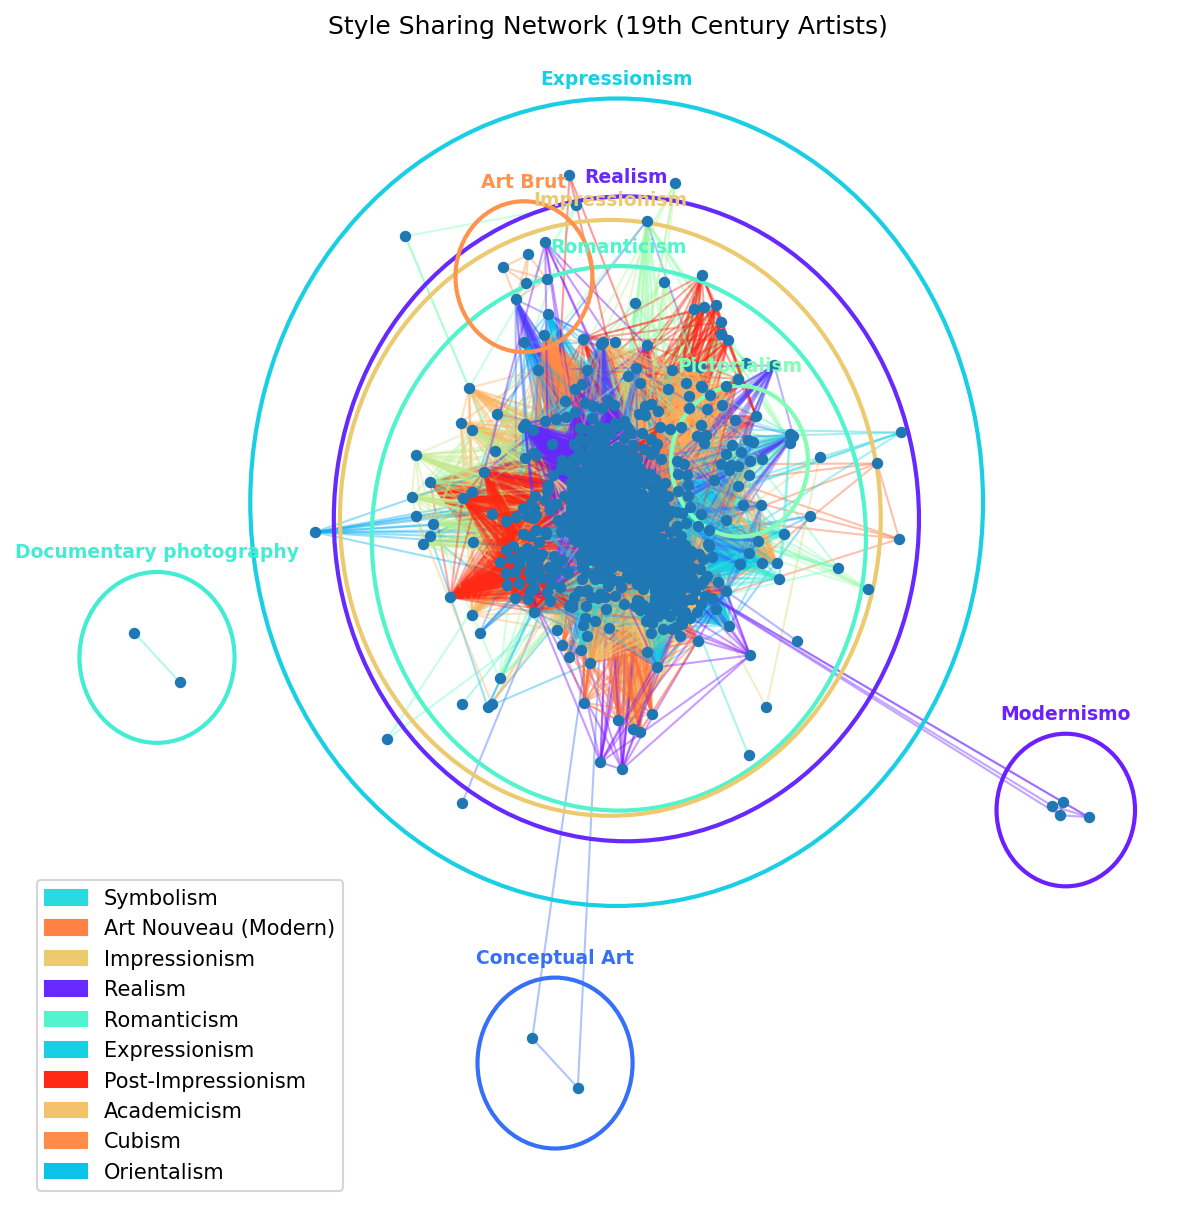

In [32]:
visualize_greedy_modularity_clusters_style(style_share_19c, "19th Century")

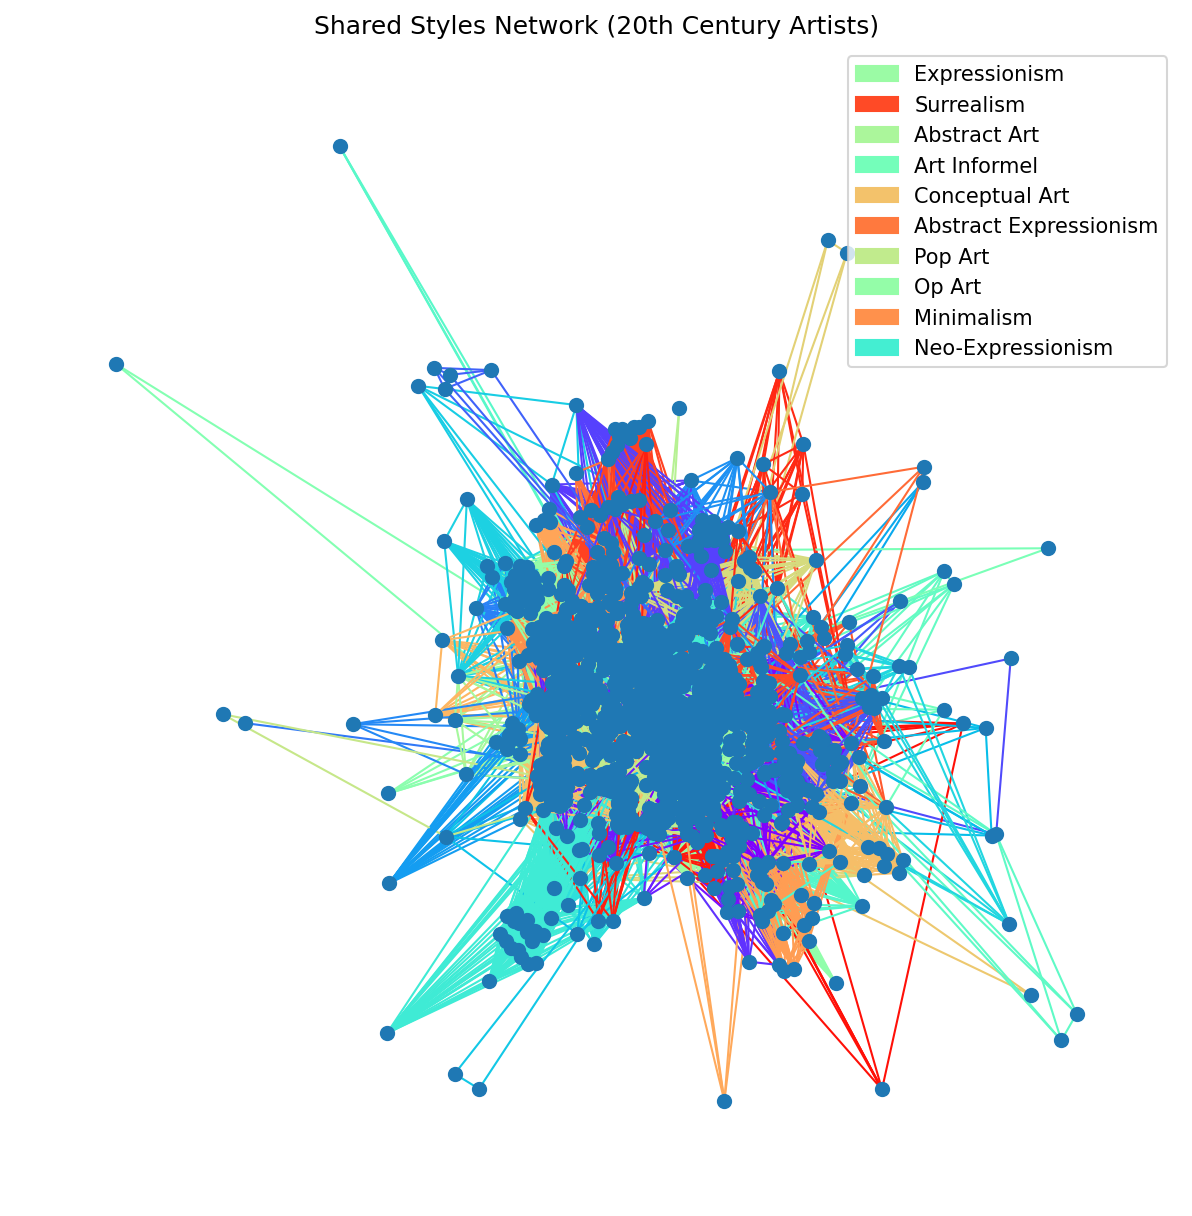

In [34]:
style_share_20c = style_share(artists_20c)
visualize_style_sharing(style_share_20c, "20th Century")

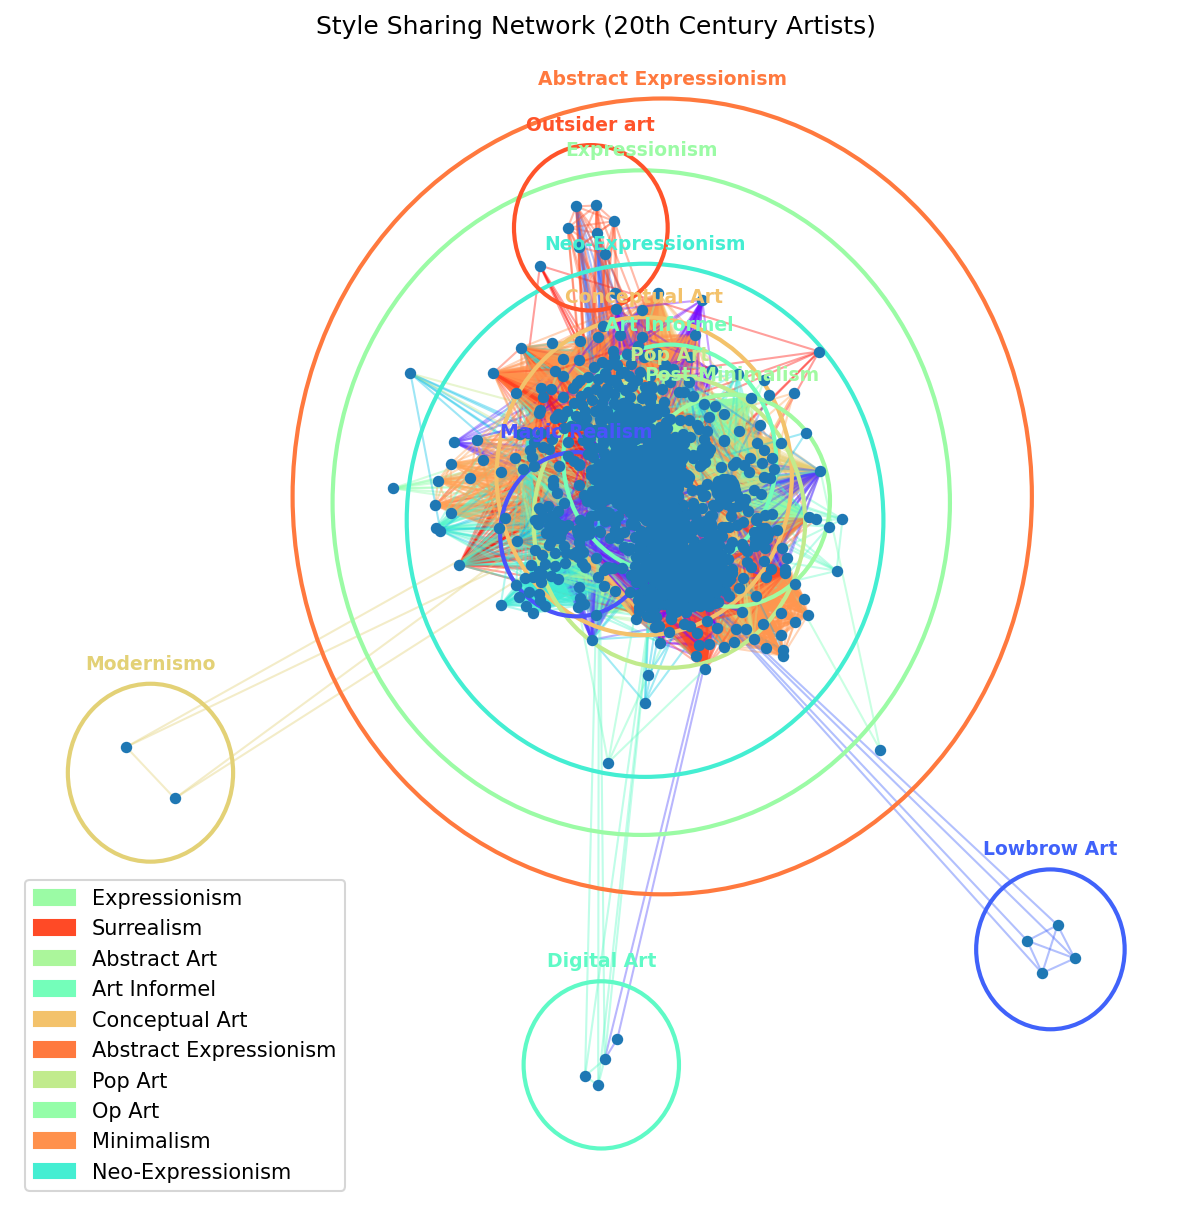

In [35]:
visualize_greedy_modularity_clusters_style(style_share_20c, "20th Century")